# Preparação dos dados


In [46]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

CSV_LIMPO = "telecomx_limpo.csv"
df = pd.read_csv(CSV_LIMPO)

cols_drop = [c for c in ["customerID"] if c in df.columns]
df = df.drop(columns=cols_drop)

df["Churn_bin"] = (df["Churn"].astype(str).str.strip().str.lower() == "yes").astype(int)

y = df["Churn_bin"].copy()
X = df.drop(columns=["Churn", "Churn_bin"])

# 5) Detectar tipos
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number, "Int64", "float64", "int64"]).columns.tolist()

print("Colunas categóricas:", cat_cols)
print("Colunas numéricas:", num_cols)

# 6) Proporção de classes
prop = y.value_counts(normalize=True).rename({1: "Churn=1", 0: "Churn=0"}) * 100
print("\nProporção de classes (%):")
print(prop.round(2))

print("""
Modelos baseados em distância (LogReg, KNN, SVM, RN) precisam de normalização.
Modelos baseados em árvore (Decision Tree, Random Forest, XGBoost) não são sensíveis à escala.
""")

preprocess_norm = ColumnTransformer(
    transformers=[
        ("num",  Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat",  Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols),
    ],
    remainder="drop"
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num",  SimpleImputer(strategy="median"), num_cols),
        ("cat",  Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols),
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nShapes — X_train: {X_train.shape}, X_test: {X_test.shape}, y: {y.shape}")



Colunas categóricas: ['customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']
Colunas numéricas: ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Contas_Diarias']

Proporção de classes (%):
Churn_bin
Churn=0    73.46
Churn=1    26.54
Name: proportion, dtype: float64

Modelos baseados em distância (LogReg, KNN, SVM, RN) precisam de normalização.
Modelos baseados em árvore (Decision Tree, Random Forest, XGBoost) não são sensíveis à escala.


Shapes — X_train: (4930, 20), X_test: (2113, 20), y: (7043,)


#🎯 Correlação e Seleção de Variáveis

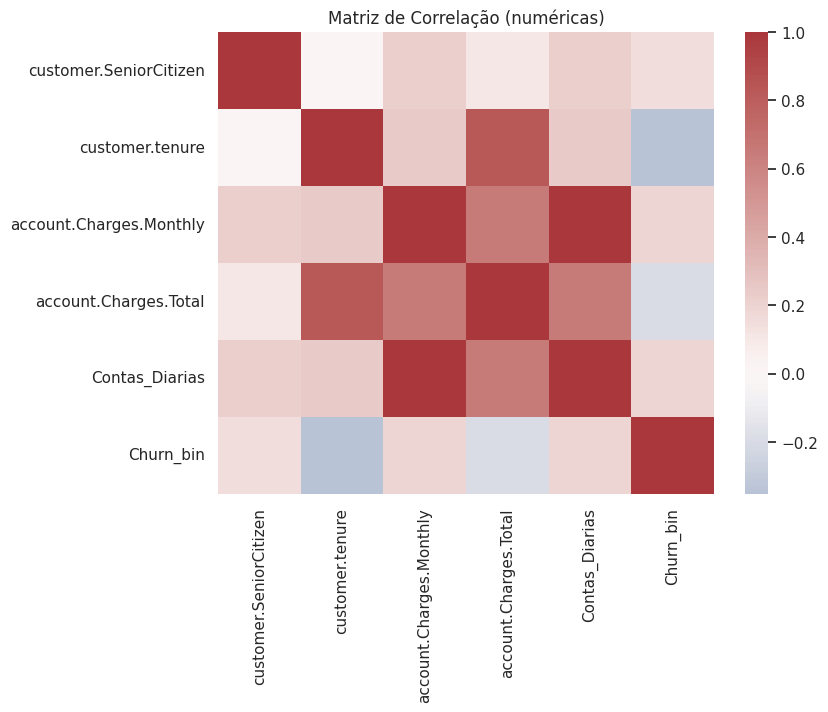


Correlação com Churn_bin (top 15):
customer.tenure           -0.352
account.Charges.Total     -0.198
Contas_Diarias             0.193
account.Charges.Monthly    0.193
customer.SeniorCitizen     0.151
Name: Churn_bin, dtype: float64


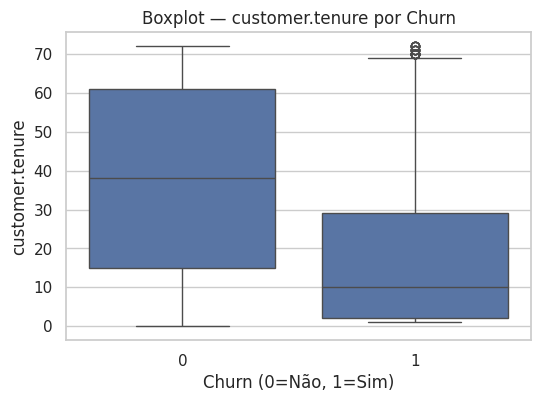

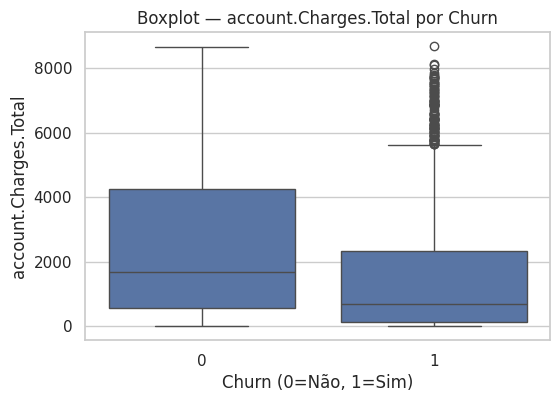

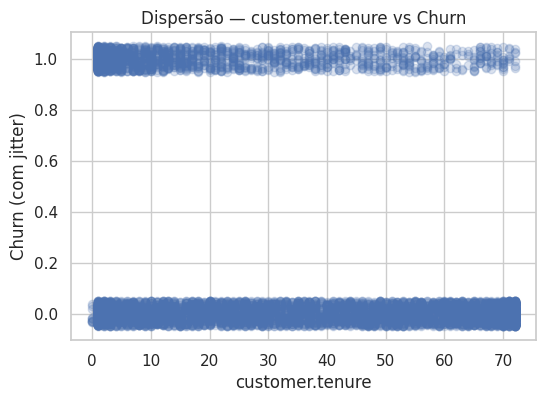

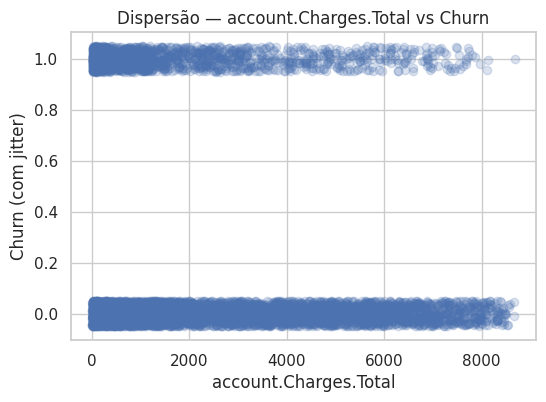

In [48]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

tmp = df.copy()
tmp["Churn_bin"] = y
num_corr_cols = tmp.select_dtypes(include=[np.number]).columns.tolist()

corr = tmp[num_corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=False, cmap="vlag", center=0)
plt.title("Matriz de Correlação (numéricas)")
plt.show()

corr_target = corr["Churn_bin"].drop("Churn_bin").sort_values(key=lambda s: s.abs(), ascending=False)
print("\nCorrelação com Churn_bin (top 15):")
print(corr_target.head(15).round(3))

for col in [c for c in ["customer.tenure", "account.Charges.Total"] if c in df.columns]:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Churn_bin", y=col)
    plt.title(f"Boxplot — {col} por Churn")
    plt.xlabel("Churn (0=Não, 1=Sim)")
    plt.show()

for col in [c for c in ["customer.tenure", "account.Charges.Total"] if c in df.columns]:
    plt.figure(figsize=(6,4))
    y_jitter = y + np.random.uniform(-0.05, 0.05, size=len(y))
    plt.scatter(df[col], y_jitter, alpha=0.2)
    plt.title(f"Dispersão — {col} vs Churn")
    plt.xlabel(col); plt.ylabel("Churn (com jitter)")
    plt.show()


#🤖 Modelagem Preditiva


===== Regressão Logística (normalizado) =====
              precision    recall  f1-score   support

           0      0.844     0.889     0.866      1552
           1      0.639     0.545     0.588       561

    accuracy                          0.797      2113
   macro avg      0.741     0.717     0.727      2113
weighted avg      0.789     0.797     0.792      2113

Acurácia: 0.797 | Precisão: 0.639 | Recall: 0.545 | F1: 0.588


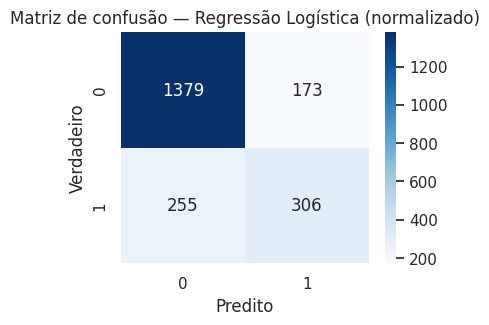


===== Random Forest (árvore, sem normalizar) =====
              precision    recall  f1-score   support

           0      0.828     0.885     0.856      1552
           1      0.607     0.490     0.542       561

    accuracy                          0.780      2113
   macro avg      0.717     0.688     0.699      2113
weighted avg      0.769     0.780     0.772      2113

Acurácia: 0.780 | Precisão: 0.607 | Recall: 0.490 | F1: 0.542


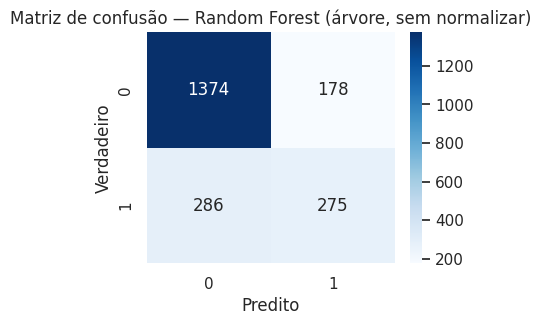


Resumo das métricas (ordenado por F1):


,modelo,acc,prec,rec,f1
0,Regressão Logística (normalizado),0.797444,0.638831,0.545455,0.588462
1,"Random Forest (árvore, sem normalizar)",0.780407,0.607064,0.490196,0.542406


In [49]:

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def avalia_modelo(nome, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n===== {nome} =====")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))
    print(f"Acurácia: {acc:.3f} | Precisão: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de confusão — {nome}")
    plt.xlabel("Predito"); plt.ylabel("Verdadeiro")
    plt.show()
    return {"modelo": nome, "acc": acc, "prec": prec, "rec": rec, "f1": f1}

modelo_lr = Pipeline(steps=[
    ("prep", preprocess_norm),
    ("clf", LogisticRegression(max_iter=200, n_jobs=None, class_weight=None, solver="lbfgs"))
])
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)
res_lr = avalia_modelo("Regressão Logística (normalizado)", y_test, pred_lr)

modelo_rf = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ))
])
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)
res_rf = avalia_modelo("Random Forest (árvore, sem normalizar)", y_test, pred_rf)

resumo = pd.DataFrame([res_lr, res_rf]).sort_values("f1", ascending=False)
print("\nResumo das métricas (ordenado por F1):")
display(resumo)


#📋  Interpretação e Conclusões


Top 10 coeficientes positivos (aumentam prob. de churn):


,feature,coef
3,account.Charges.Total,0.7021
16,internet.InternetService_Fiber optic,0.6868
30,account.Contract_Month-to-month,0.6044
37,account.PaymentMethod_Electronic check,0.2333
11,phone.PhoneService_No,0.1732
24,internet.TechSupport_No,0.0921
34,account.PaperlessBilling_Yes,0.0886
0,customer.SeniorCitizen,0.0629
18,internet.OnlineSecurity_No,0.0337
14,phone.MultipleLines_Yes,0.0115



Top 10 coeficientes negativos (reduzem prob. de churn):


,feature,coef
1,customer.tenure,-1.4552
17,internet.InternetService_No,-0.8596
32,account.Contract_Two year,-0.7018
12,phone.PhoneService_Yes,-0.4101
25,internet.TechSupport_Yes,-0.3290
33,account.PaperlessBilling_No,-0.3255
19,internet.OnlineSecurity_Yes,-0.2706
13,phone.MultipleLines_No,-0.2484
10,customer.Dependents_Yes,-0.2203
26,internet.StreamingTV_No,-0.2200



Importância de variáveis — Random Forest (top 15):


,feature,importance
3,account.Charges.Total,0.142303
1,customer.tenure,0.136055
2,account.Charges.Monthly,0.118199
4,Contas_Diarias,0.100769
30,account.Contract_Month-to-month,0.065727
37,account.PaymentMethod_Electronic check,0.031484
16,internet.InternetService_Fiber optic,0.028585
32,account.Contract_Two year,0.021858
0,customer.SeniorCitizen,0.017404
6,customer.gender_Male,0.016694


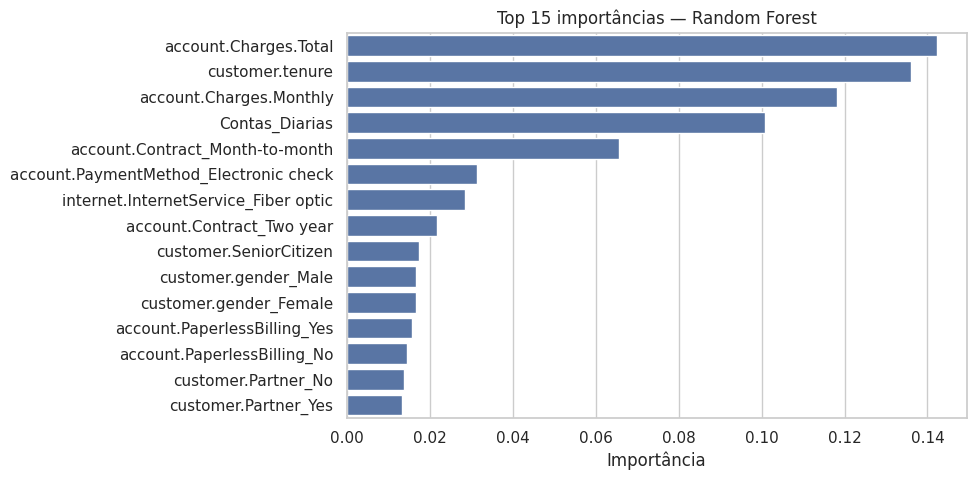


Projeto: Predição de Evasão (Churn) — TelecomX

Objetivo
Analisar fatores relacionados à evasão e treinar modelos para prever churn.

Preparação de Dados
- Base utilizada: telecomx_limpo.csv (colunas relevantes, dados padronizados).
- Remoção de identificadores: customerID.
- Conversões: alvo Churn → binário (Churn_bin).
- Codificação: One-Hot Encoding para variáveis categóricas.
- Tratamento de ausentes: imputação (mediana para numéricas, mais frequente para categóricas).
- Nota: normalização aplicada apenas no pipeline de Regressão Logística; Random Forest não requer escala.

Balanceamento
Proporção de classes (aprox.): {'Churn=0': 73.4630129206304, 'Churn=1': 26.536987079369588}

Correlação e Sinais
- Foram inspecionadas correlações entre variáveis numéricas e o alvo (heatmap).
- Padrões visuais com boxplots e dispersões indicaram diferenças em tenure e Charges.Total entre churn e não churn.

Modelos e Justificativa
- Regressão Logística (com normalização): modelo linear adequado para classificar e interpretar coeficientes; sensível à escala.
- Random Forest (sem normalização): modelo baseado em árvores, robusto a não linearidades e a colunas OHE; não sensível à escala.

Métricas de Desempenho (teste)
- Regressão Logística (normalizado): Acurácia=0.797, Precisão=0.639, Recall=0.545, F1=0.588
- Random Forest (árvore, sem normalizar): Acurácia=0.780, Precisão=0.607, Recall=0.490, F1=0.542

Comparação Crítica
- O melhor modelo é o que apresentou maior F1 (maior equilíbrio entre precisão e recall). Ver resumo acima.
- Possível overfitting se Acurácia de treino >> teste (verificar via validação cruzada e regularização/hiperparâmetros).
- Possível underfitting se todas as métricas forem baixas: considerar mais complexidade (mais árvores/profundidade) ou novas variáveis/engenharia.

Interpretação — Regressão Logística (efeito no log-odds de Churn)
Principais coeficientes positivos (aumentam a probabilidade de churn)
- account.Charges.Total: 0.702
- internet.InternetService_Fiber optic: 0.687
- account.Contract_Month-to-month: 0.604
- account.PaymentMethod_Electronic check: 0.233
- phone.PhoneService_No: 0.173
- internet.TechSupport_No: 0.092
- account.PaperlessBilling_Yes: 0.089
- customer.SeniorCitizen: 0.063
- internet.OnlineSecurity_No: 0.034
- phone.MultipleLines_Yes: 0.011

Principais coeficientes negativos (reduzem a probabilidade de churn)
- customer.tenure: -1.455
- internet.InternetService_No: -0.860
- account.Contract_Two year: -0.702
- phone.PhoneService_Yes: -0.410
- internet.TechSupport_Yes: -0.329
- account.PaperlessBilling_No: -0.325
- internet.OnlineSecurity_Yes: -0.271
- phone.MultipleLines_No: -0.248
- customer.Dependents_Yes: -0.220
- internet.StreamingTV_No: -0.220

Interpretação — Random Forest (importâncias)
Top variáveis por importância
- account.Charges.Total: 0.1423
- customer.tenure: 0.1361
- account.Charges.Monthly: 0.1182
- Contas_Diarias: 0.1008
- account.Contract_Month-to-month: 0.0657
- account.PaymentMethod_Electronic check: 0.0315
- internet.InternetService_Fiber optic: 0.0286
- account.Contract_Two year: 0.0219
- customer.SeniorCitizen: 0.0174
- customer.gender_Male: 0.0167

Recomendações de Negócio
1. Foco em clientes com baixo tenure e perfis de contrato/método de pagamento associados a maior churn: campanhas de retenção e ofertas específicas.
2. Incentivar contratos de maior duração e simplificar métodos de pagamento (ex.: débito automático).
3. Monitorar quedas/saltos em faturamento (Charges.Monthly/Contas_Diarias) como gatilhos de atendimento proativo.
4. Usar os scores do melhor modelo para priorizar ações de Customer Success e cross-sell.

Próximos Passos
- Otimização por validação cruzada e busca de hiperparâmetros (Grid/Random/Bayesian Search).
- Avaliar técnicas de balanceamento (class_weight, SMOTE) se o desequilíbrio for relevante.
- Criar pipeline de produção e monitoramento de drift de dados e performance do modelo.


In [53]:

from IPython.display import Markdown, display

def nomes_features(transformer: ColumnTransformer) -> list:
    nomes = []
    for name, trans, cols in transformer.transformers_:
        if name == "remainder" and trans == "drop":
            continue
        if hasattr(trans, "get_feature_names_out"):

            try:
                out = trans.get_feature_names_out(cols)
            except:
                out = trans.get_feature_names_out()
            nomes.extend(out.tolist())
        else:

            if isinstance(cols, list):
                nomes.extend(cols)
            else:
                nomes.extend(transformer._feature_names_in)[cols]
    return nomes

prep_lr: ColumnTransformer = modelo_lr.named_steps["prep"]
feat_names_lr = nomes_features(prep_lr)
coefs = modelo_lr.named_steps["clf"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feat_names_lr, "coef": coefs})
coef_df["impacto_abs"] = coef_df["coef"].abs()
coef_top_pos = coef_df.sort_values("coef", ascending=False).head(10)
coef_top_neg = coef_df.sort_values("coef", ascending=True).head(10)

print("\nTop 10 coeficientes positivos (aumentam prob. de churn):")
display(coef_top_pos[["feature","coef"]].round(4))
print("\nTop 10 coeficientes negativos (reduzem prob. de churn):")
display(coef_top_neg[["feature","coef"]].round(4))


prep_rf: ColumnTransformer = modelo_rf.named_steps["prep"]
feat_names_rf = nomes_features(prep_rf)
imps = modelo_rf.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": feat_names_rf, "importance": imps}).sort_values("importance", ascending=False)
print("\nImportância de variáveis — Random Forest (top 15):")
display(imp_df.head(15))

plt.figure(figsize=(8,5))
sns.barplot(data=imp_df.head(15), x="importance", y="feature")
plt.title("Top 15 importâncias — Random Forest")
plt.xlabel("Importância"); plt.ylabel("")
plt.show()

def linha_metricas(row):
    return f"- {row['modelo']}: Acurácia={row['acc']:.3f}, Precisão={row['prec']:.3f}, Recall={row['rec']:.3f}, F1={row['f1']:.3f}"

metricas_txt = "\n".join(resumo.apply(linha_metricas, axis=1).tolist())

top_pos_txt = "\n".join([f"- {r.feature}: {r.coef:.3f}" for r in coef_top_pos.itertuples()])
top_neg_txt = "\n".join([f"- {r.feature}: {r.coef:.3f}" for r in coef_top_neg.itertuples()])
imp_rf_txt  = "\n".join([f"- {r.feature}: {r.importance:.4f}" for r in imp_df.head(10).itertuples()])

relatorio = f"""
Projeto: Predição de Evasão (Churn) — TelecomX

Objetivo
Analisar fatores relacionados à evasão e treinar modelos para prever churn.

Preparação de Dados
- Base utilizada: telecomx_limpo.csv (colunas relevantes, dados padronizados).
- Remoção de identificadores: customerID.
- Conversões: alvo Churn → binário (Churn_bin).
- Codificação: One-Hot Encoding para variáveis categóricas.
- Tratamento de ausentes: imputação (mediana para numéricas, mais frequente para categóricas).
- Nota: normalização aplicada apenas no pipeline de Regressão Logística; Random Forest não requer escala.

Balanceamento
Proporção de classes (aprox.): {prop.to_dict()}

Correlação e Sinais
- Foram inspecionadas correlações entre variáveis numéricas e o alvo (heatmap).
- Padrões visuais com boxplots e dispersões indicaram diferenças em tenure e Charges.Total entre churn e não churn.

Modelos e Justificativa
- Regressão Logística (com normalização): modelo linear adequado para classificar e interpretar coeficientes; sensível à escala.
- Random Forest (sem normalização): modelo baseado em árvores, robusto a não linearidades e a colunas OHE; não sensível à escala.

Métricas de Desempenho (teste)
{metricas_txt}

Comparação Crítica
- O melhor modelo é o que apresentou maior F1 (maior equilíbrio entre precisão e recall). Ver resumo acima.
- Possível overfitting se Acurácia de treino >> teste (verificar via validação cruzada e regularização/hiperparâmetros).
- Possível underfitting se todas as métricas forem baixas: considerar mais complexidade (mais árvores/profundidade) ou novas variáveis/engenharia.

Interpretação — Regressão Logística (efeito no log-odds de Churn)
Principais coeficientes positivos (aumentam a probabilidade de churn)
{top_pos_txt}

Principais coeficientes negativos (reduzem a probabilidade de churn)
{top_neg_txt}

Interpretação — Random Forest (importâncias)
Top variáveis por importância
{imp_rf_txt}

Recomendações de Negócio
1. Foco em clientes com baixo tenure e perfis de contrato/método de pagamento associados a maior churn: campanhas de retenção e ofertas específicas.
2. Incentivar contratos de maior duração e simplificar métodos de pagamento (ex.: débito automático).
3. Monitorar quedas/saltos em faturamento (Charges.Monthly/Contas_Diarias) como gatilhos de atendimento proativo.
4. Usar os scores do melhor modelo para priorizar ações de Customer Success e cross-sell.

Próximos Passos
- Otimização por validação cruzada e busca de hiperparâmetros (Grid/Random/Bayesian Search).
- Avaliar técnicas de balanceamento (class_weight, SMOTE) se o desequilíbrio for relevante.
- Criar pipeline de produção e monitoramento de drift de dados e performance do modelo.
"""

display(Markdown(relatorio))

